## Results of Host Prediction
### Dataset: EMBL mapping, Vertebrates, Non-IDV

**Models**: FNN, CNN, RNN, LSTM, TF

**Positional Embedding**: Sin-Cos

**Maximum Sequence Length**: 1036

**Classification**: Multi-class

**\# classes**: 5

**\# train samples** = 

**\# validation samples** = 

**\# test samples** = 

In [1]:
import seaborn

In [2]:
seaborn.__version__

'0.13.2'

In [3]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../..']

In [4]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [36]:
output_filepaths = {
    "Pretraining: Viruses infecting Vertebrates": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv/20251216/vertebrates_pretraining/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv"),
    "Pretraining: All viruses": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20240826/host_multi/fine_tuning_hybrid_cls/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_hybrid_attention_msl256s64ae_bn_fnn_2l_d1024_lr1e-4_output.csv"),
    
}

In [67]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    classes = None
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        classes = list(set(cols) - set([itr_col, experiment_col, y_true_col]))
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v+1
    metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    print(metadata_formatted)
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams.update({'font.size': 14})
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [.7, 3]})
    #color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    color_palette = sns.color_palette("Set2", n_colors=2)
    color_palette = [color_palette[1], color_palette[0]]
    axs = axs.flatten()
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", 
                order=metadata_sorted, palette=color_palette, ax=axs[1], legend=True)
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("Macro-AUPRC", size=14)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.35, 1), ncol=2, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=14)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    plt.subplots_adjust(wspace=0.01)
    #plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

Read output Pretraining: Viruses infecting Vertebrates = (15845, 7)
Read output Pretraining: All viruses = (15845, 7)
{'Human': 'Human (90.79%)', 'Pig': 'Pig (4.04%)', 'Capybara': 'Capybara (1.96%)', 'Himalayan marmot': 'Himalayan marmot (1.70%)', 'Red junglefowl': 'Red junglefowl (1.51%)'}


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


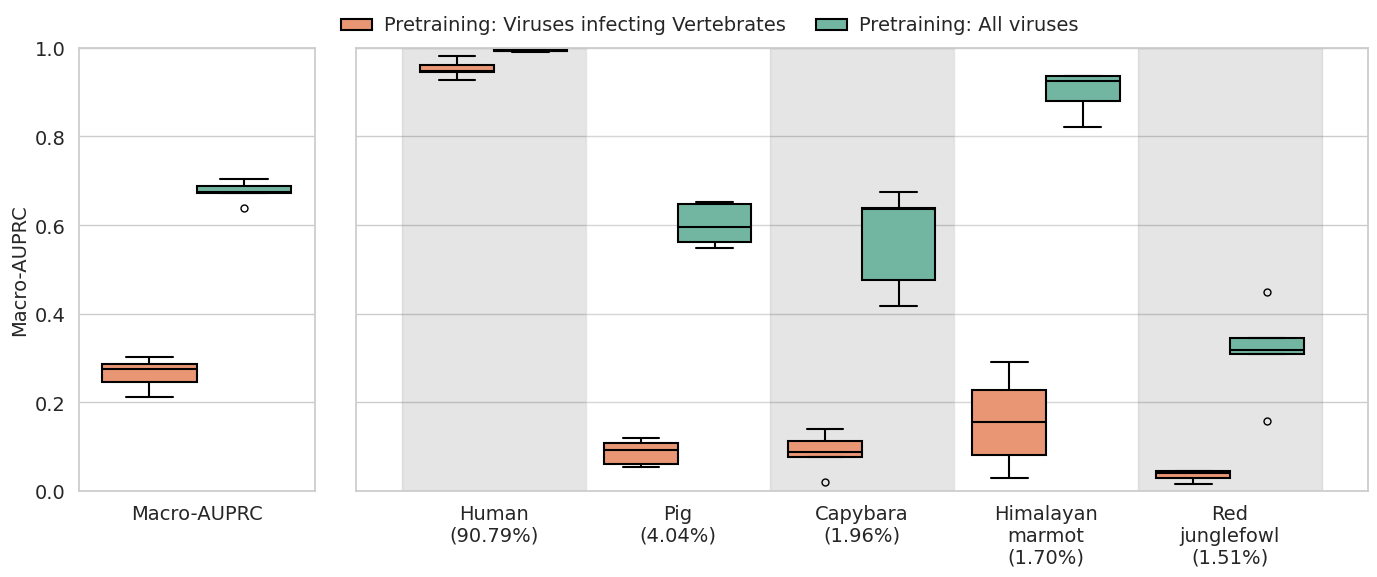

In [69]:
classes = ["Human", "Capybara", "Himalayan marmot", "Pig", "Red junglefowl"]
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes, 
                          figure_output_filepath=os.path.join(os.getcwd(), "..", "..", "..", "..", f"output/visualization/haven/host_multi_uniref90_combined_auprc_pretraining_datasets_variation.pdf"))

In [11]:
auprc_results_df[["model", "class", "auprc"]].groupby(["model", "class"]).agg(["mean", "std", "median", iqr])

auprc            \
                                                               mean       std   
model                            class                                          
HAVEN                            Capybara (1.96%)          0.568408  0.114120   
                                 Himalayan marmot (1.70%)  0.899886  0.049819   
                                 Human (90.79%)            0.993320  0.001634   
                                 Macro-AUPRC               0.675713  0.023920   
                                 Pig (4.04%)               0.601161  0.048049   
                                 Red junglefowl (1.51%)    0.315789  0.104314   
HAVEN\n(Vertebrates Pretraining) Capybara (1.96%)          0.087161  0.044871   
                                 Himalayan marmot (1.70%)  0.157001  0.106463   
                                 Human (90.79%)            0.952894  0.020074   
                                 Macro-AUPRC               0.263602  0.036201   
                                 Pig (4.04%)               0.086497  0.028617   
                                 Red junglefowl (1.51%)    0.034459  0.011966   

                                                                               
                                                             median       iqr  
model                            class                                         
HAVEN                            Capybara (1.96%)          0.636936  0.161846  
                                 Himalayan marmot (1.70%)  0.924577  0.055591  
                                 Human (90.79%)            0.993013  0.001608  
                                 Macro-AUPRC               0.674083  0.016421  
                                 Pig (4.04%)               0.596464  0.087513  
                                 Red junglefowl (1.51%)    0.316946  0.037637  
HAVEN\n(Vertebrates Pretraining) Capybara (1.96%)          0.086685  0.036467  
                                 Himalayan marmot (1.70%)  0.155772  0.145551  
                                 Human (90.79%)            0.948149  0.015442  
                                 Macro-AUPRC               0.274975  0.040670  
                                 Pig (4.04%)               0.091754  0.047260  
                                 Red junglefowl (1.51%)    0.039479  0.015858

In [12]:
auprc_results_df[auprc_results_df["class"] == "Human (90.79%)"]["auprc"].median()

0.9866012538197578